# Step 3 — Model Inference & Evaluation

**Research question:** Can any existing pretrained PhaseNet weight serve as a
competent *global* phase picker across local, regional, and teleseismic distances?

**Approach:** Run all PhaseNet pretrained weights through `benchmark_waveforms.hdf5`
and evaluate on three tasks following Münchmeyer et al. (2022):

| Task | Metric | Description |
|------|--------|-------------|
| 1 — Detection | Recall @ threshold | Does the model find the phase? |
| 2 — Phase ID | MCC | Does it label P vs S correctly? |
| 3 — Onset time | MAE, RMSE, % outliers | How accurate is the pick time? |

**In-domain vs cross-domain:** Every result is reported both ways.
The `trained_models` column in the manifest identifies which dataset each trace
belongs to — when evaluating `PhaseNet/stead`, STEAD traces are excluded from
the cross-domain split. The MLAAPDE teleseismic traces are 100% cross-domain
for every model (none was trained on MLAAPDE).

```
benchmark_waveforms.hdf5
        │
        ▼
 3.1  Setup & model inventory
        │
        ▼
 3.2  Inference loop
        │   For each PhaseNet weight:
        │     load model → batch inference → extract P/S peaks → save
        ▼
 3.3  Metric computation
        │   Detection recall · Phase ID MCC · Onset MAE/RMSE
        │   Broken down by: model · dataset · distance bin · physics bin
        ▼
 3.4  Cross-domain analysis
        │   In-domain vs cross-domain performance matrices
        ▼
 3.5  Visualisation
        │   Heatmaps · residual distributions · SNR curves · distance breakdown
        ▼
     step3_results.parquet  +  step3_metrics.csv
```


## 3.1  Imports & Configuration


In [14]:
import numpy as np
import pandas as pd
import h5py, warnings
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict
import scipy.signal
import torch
import seisbench.models as sbm

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ──────────────────────────────────────────────────────────────────
HDF5_PATH    = Path("benchmark_waveforms.hdf5")
INDEX_PATH   = Path("benchmark_waveforms_index.csv")
RESULTS_PATH = Path("step3_results.parquet")
METRICS_PATH = Path("step3_metrics.csv")

assert HDF5_PATH.exists(),  "benchmark_waveforms.hdf5 not found — run Step 2 first"
assert INDEX_PATH.exists(), "benchmark_waveforms_index.csv not found — run Step 2 first"

# ── Inference parameters ───────────────────────────────────────────────────
BATCH_SIZE      = 64       # traces per GPU/CPU batch
TARGET_SR       = 100      # Hz
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD_P     = 0.3      # probability threshold for P detection
THRESHOLD_S     = 0.3      # probability threshold for S detection
MIN_PEAK_DIST   = 50       # minimum samples between peaks

# Residual outlier thresholds (Münchmeyer et al. 2022)
OUTLIER_REGIONAL     = 0.45  # seconds
OUTLIER_TELESEISMIC  = 1.50  # seconds

print(f"Device       : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Threshold P/S: {THRESHOLD_P} / {THRESHOLD_S}")


Device       : cuda
GPU          : NVIDIA GeForce RTX 3090
Batch size   : 64
Threshold P/S: 0.3 / 0.3


## 3.1b  Model Inventory

All 16 PhaseNet pretrained weights available in SeisBench, grouped by tier
from Step 1's model tiering analysis.

**Tier A (Generalist candidates):** `stead`, `instance`, `neic`
**Tier B (Specialty/large-regional):** `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc`
**Tier C (Regional baselines):** `scedc`, `ethz`, `iquique`, `lendb`, `original`
**Tier D (Teleseismic):** `geofon`

The `trained_models` column in the manifest maps each trace to the weight(s)
that were trained on its source dataset — used for in-domain/cross-domain splits.

**Benchmark datasets (Step 2 output):**

| Dataset | In benchmark | Model trained on it |
|---------|-------------|---------------------|
| stead | yes | `stead`, `original` |
| instancecounts | yes | `instance` |
| pnw | yes | — |
| txed | yes | — |
| mlaapde | yes | — |
| ethz | yes | `ethz` |
| pisdl | yes | `pisdl` |
| ceed | yes | — |
| vcseis | yes | — |
| aq2009gm | yes | — |
| cwa | yes | — |
| obst2024 | skipped | `obs` |
| scedc | not in benchmark | `scedc` (→ all traces cross-domain) |
| iquique | not in benchmark | `iquique` (→ all traces cross-domain) |

In [15]:
# PhaseNet weights to evaluate — ordered by tier
PHASENET_WEIGHTS = {
    # Tier A — Generalist candidates
    "stead":       {"tier": "A", "trained_on": "stead",          "description": "Northern California (STEAD)"},
    "instance":    {"tier": "A", "trained_on": "instance",        "description": "Italy/Mediterranean (INSTANCE)"},
    "neic":        {"tier": "A", "trained_on": "neic",            "description": "Global teleseismic (NEIC)"},
    # Tier B — Specialty / large-regional
    "diting":      {"tier": "B", "trained_on": None,              "description": "China (~2.7M events)"},
    "obs":         {"tier": "B", "trained_on": "obst2024",        "description": "Ocean-bottom seismometers"},
    "volpick":     {"tier": "B", "trained_on": None,              "description": "Volcano-tectonic events"},
    "pisdl":       {"tier": "B", "trained_on": "pisdl",           "description": "Induced seismicity"},
    "phasenet_sn": {"tier": "B", "trained_on": None,              "description": "SNet offshore Japan"},
    "jma":         {"tier": "B", "trained_on": None,              "description": "JMA Japan"},
    "jma_wc":      {"tier": "B", "trained_on": None,              "description": "JMA Japan (wider conv)"},
    # Tier C — Regional baselines
    "scedc":       {"tier": "C", "trained_on": "scedc",           "description": "Southern California (SCEDC)"},
    "ethz":        {"tier": "C", "trained_on": "ethz",            "description": "Switzerland (ETHZ)"},
    "iquique":     {"tier": "C", "trained_on": "iquique",         "description": "Northern Chile (Iquique)"},
    "lendb":       {"tier": "C", "trained_on": None,              "description": "LenDB (Italy, P-only)"},
    "original":    {"tier": "C", "trained_on": "stead",           "description": "Original PhaseNet (Zhu & Beroza 2018)"},
    # Tier D — Teleseismic
    "geofon":      {"tier": "D", "trained_on": None,              "description": "Teleseismic broadband (GEOFON)"},
}

print(f"Total weights to evaluate: {len(PHASENET_WEIGHTS)}")
for tier in ["A","B","C","D"]:
    ws = [w for w,v in PHASENET_WEIGHTS.items() if v["tier"]==tier]
    print(f"  Tier {tier}: {ws}")

# Verify all weights are available in SeisBench
print("\nVerifying availability...")
available, missing = [], []
for weight in PHASENET_WEIGHTS:
    try:
        sbm.PhaseNet.from_pretrained(weight, update=False)
        available.append(weight)
    except Exception as e:
        missing.append((weight, str(e)[:60]))

print(f"  Available: {len(available)}")
if missing:
    print(f"  Missing  : {len(missing)}")
    for w, e in missing:
        print(f"    {w}: {e}")

Total weights to evaluate: 16
  Tier A: ['stead', 'instance', 'neic']
  Tier B: ['diting', 'obs', 'volpick', 'pisdl', 'phasenet_sn', 'jma', 'jma_wc']
  Tier C: ['scedc', 'ethz', 'iquique', 'lendb', 'original']
  Tier D: ['geofon']

Verifying availability...
  Available: 15
  Missing  : 1
    pisdl: Weights require seisbench version at least 0.10.1, but the i


## 3.2  Load Benchmark


In [16]:
# ── Load index and manifest ────────────────────────────────────────────────
index = pd.read_csv(INDEX_PATH)
ok    = index[index["status"] == "ok"].copy().reset_index(drop=True)

manifest = pd.read_csv("benchmark_manifest.csv")

# Merge physics columns — drop any existing source_month first to avoid
# duplicate columns from repeated runs
ok = ok.drop(columns=[c for c in ok.columns if "source_month" in c], errors="ignore")

phys = ["trace_name","magnitude","depth_km","distance_km","ts_tp_s",
        "dist_bin","depth_bin","mag_bin","trained_models","tectonic_type",
        "p_arrival_sample","s_arrival_sample","source_month","dataset"]
ok = ok.merge(
    manifest[[c for c in phys if c in manifest.columns]],
    on="trace_name", how="left", suffixes=("","_m"))

# Drop any _m duplicate columns created by the merge
ok = ok.drop(columns=[c for c in ok.columns if c.endswith("_m")], errors="ignore")

print(f"Benchmark traces: {len(ok):,}")
print(ok.groupby("dataset")["trace_name"].count().rename("n").to_string())

print(f"\nColumn NaN check:")
for col in ["p_arrival_sample","s_arrival_sample","source_month","dist_bin"]:
    if col in ok.columns:
        n_nan = ok[col].isna().sum()
        print(f"  {col:25s}: {n_nan:,} NaN  "
              f"({'expected — S-only or non-MLAAPDE' if n_nan > 0 else 'clean'})")

print(f"\nDistance bins:")
print(ok["dist_bin"].value_counts().to_string())

# ── Sanity check: the 1 NaN p_arrival_sample is the S-only MLAAPDE trace ──
bad = ok[ok["p_arrival_sample"].isna()]
if len(bad) > 0:
    print(f"\nTraces with no P arrival ({len(bad)}):")
    print(bad[["trace_name","dataset",
               "has_p_pick","has_s_pick"]].to_string(index=False))


Benchmark traces: 32,144
dataset
aq2009gm          1363
ceed              4530
cwa                195
ethz              1365
instancecounts    8406
mlaapde           1444
pisdl              762
pnw               2333
stead             9366
txed              2267
vcseis             113

Column NaN check:
  p_arrival_sample         : 43 NaN  (expected — S-only or non-MLAAPDE)
  s_arrival_sample         : 2,338 NaN  (expected — S-only or non-MLAAPDE)
  source_month             : 30,700 NaN  (expected — S-only or non-MLAAPDE)
  dist_bin                 : 308 NaN  (expected — S-only or non-MLAAPDE)

Distance bins:
dist_bin
local (<150km)           15915
regional (150-1500km)    14477
teleseismic (>1500km)     1444

Traces with no P arrival (43):
           trace_name  dataset  has_p_pick  has_s_pick
 bucket0$846,:3,:8751 aq2009gm       False        True
bucket13$347,:3,:8751 aq2009gm       False        True
bucket12$874,:3,:8751 aq2009gm       False        True
bucket17$985,:3,:8751 aq2009g

## 3.3  Inference Loop

Reads preprocessed 3000-sample / 100 Hz windows from `benchmark_waveforms.hdf5`
(produced by Step 2). The HDF5 is opened once and kept open for all model weights.

**Why this is fast vs the old `annotate()` approach:**
- Single flat HDF5 file — no per-trace file opens across 11 source datasets/shards
- `model.forward()` called once per batch of 64 traces on the RTX 3090
- No sliding-window or blinding overhead — windows are exactly 3000 samples

**Normalization:** Each batch is demeaned + unit-std per component before the
forward pass, matching what `annotate()` applies internally. The step-2 windows
are already in this form, so this is a near no-op that guards against edge cases.

**Peak search:** The output probability trace `pred[b, 0, :]` (P) and
`pred[b, 1, :]` (S) are searched within ±5 s of the known `p_in_window` /
`s_in_window` positions from the index. Residual = `(peak − true) / SR` in seconds.

**`in_samples` padding:** PhaseNet's canonical `in_samples = 3001`; the stored
windows are 3000 samples. The batch is zero-padded to 3001 before the forward
pass and output is trimmed back to 3000 — no effect on peak positions.

In [17]:
SEARCH_WINDOW_S = 5.0   # seconds either side of known arrival to search for peak


def _normalize_batch(batch):
    """Per-component demean + unit-std.  batch: (B, 3, T) → (B, 3, T) float32."""
    b   = batch - batch.mean(axis=-1, keepdims=True)
    std = b.std(axis=-1, keepdims=True)
    std[std < 1e-10] = 1.0
    return (b / std).astype(np.float32)


def run_inference_batched(weight_name, ok_df, hf):
    """
    Batched GPU inference on benchmark_waveforms.hdf5.

    Reads 3000-sample / 100 Hz windows (already preprocessed by Step 2),
    applies per-component normalization, stacks into GPU batches, and calls
    model.forward() once per batch. p_in_window / s_in_window from the index
    give the exact arrival positions — no raw source file access needed.
    """
    model = sbm.PhaseNet.from_pretrained(weight_name, update=False)
    model.eval()
    model.to(DEVICE)

    # PhaseNet's canonical in_samples=3001; pad stored 3000-sample windows by 1
    n_in   = int(getattr(model, "in_samples", 3001))
    SEARCH = int(SEARCH_WINDOW_S * TARGET_SR)   # 500 samples at 100 Hz

    results = {}
    rows    = [(idx, row) for idx, row in ok_df.iterrows()]

    for start in range(0, len(rows), BATCH_SIZE):
        batch_rows  = rows[start : start + BATCH_SIZE]
        waves, meta = [], []

        for idx, row in batch_rows:
            tname = row["trace_name"]
            if tname not in hf["waveforms"]:
                results[idx] = {"error": "not_in_hdf5"}
                continue
            waves.append(hf["waveforms"][tname][:])   # (3, 3000) float32
            meta.append((idx, row))

        if not waves:
            continue

        batch_np = _normalize_batch(np.stack(waves))   # (B, 3, 3000)
        wave_len = batch_np.shape[-1]

        # Pad to model's expected in_samples if needed (3000 → 3001)
        if wave_len < n_in:
            batch_np = np.pad(batch_np, ((0, 0), (0, 0), (0, n_in - wave_len)))

        batch_t = torch.tensor(batch_np, dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            out = model(batch_t)

        # Normalise output to (B, T) arrays for P and S regardless of
        # whether the model returns a tensor (B, C, T) or a tuple (p, s)
        if isinstance(out, (tuple, list)):
            p_full = out[0].cpu().numpy()   # (B, T)
            s_full = out[1].cpu().numpy()
        else:
            out_np = out.cpu().numpy()      # (B, C, T) — C[0]=P, C[1]=S
            p_full = out_np[:, 0, :]
            s_full = out_np[:, 1, :]

        # Trim back to 3000 if we padded
        p_full = p_full[:, :wave_len]
        s_full = s_full[:, :wave_len]

        for i, (idx, row) in enumerate(meta):
            p_in = int(row["p_in_window"])
            s_in = int(row["s_in_window"])

            # ── P peak ───────────────────────────────────────────────────
            p_prob = 0.0;  p_res = np.nan
            if p_in >= 0:
                ps = max(0, p_in - SEARCH);  pe = min(wave_len, p_in + SEARCH)
                pk = int(np.argmax(p_full[i, ps:pe])) + ps
                p_prob = float(p_full[i, pk])
                p_res  = (pk - p_in) / TARGET_SR

            # ── S peak ───────────────────────────────────────────────────
            s_prob = 0.0;  s_res = np.nan
            if s_in >= 0:
                ss = max(0, s_in - SEARCH);  se = min(wave_len, s_in + SEARCH)
                sk = int(np.argmax(s_full[i, ss:se])) + ss
                s_prob = float(s_full[i, sk])
                s_res  = (sk - s_in) / TARGET_SR

            results[idx] = {
                "p_prob":  round(p_prob, 4),
                "p_res_s": round(float(p_res), 4) if not np.isnan(p_res) else np.nan,
                "s_prob":  round(s_prob, 4),
                "s_res_s": round(float(s_res), 4) if not np.isnan(s_res) else np.nan,
            }

    model.cpu()
    del model
    torch.cuda.empty_cache()
    return results


# ── Main inference loop ───────────────────────────────────────────────────
all_results = []

print(f"Running batched inference for {len(available)} weights "
      f"over {len(ok):,} traces  (batch={BATCH_SIZE}, device={DEVICE})...")

with h5py.File(HDF5_PATH, "r") as hf:
    for weight_name in tqdm(available, desc="Models"):
        print(f"  {weight_name}...", end=" ", flush=True)
        try:
            preds = run_inference_batched(weight_name, ok, hf)
        except Exception as e:
            print(f"FAILED: {e}")
            continue

        n_ok  = sum(1 for v in preds.values() if "error" not in v)
        n_err = len(preds) - n_ok
        print(f"{n_ok:,} ok  |  {n_err:,} errors")

        for idx, row in ok.iterrows():
            pred = preds.get(idx, {})
            if "error" in pred or not pred:
                continue
            all_results.append({
                "weight":         weight_name,
                "tier":           PHASENET_WEIGHTS[weight_name]["tier"],
                "trace_name":     row["trace_name"],
                "dataset":        row["dataset"],
                "dist_bin":       row.get("dist_bin",  np.nan),
                "depth_bin":      row.get("depth_bin", np.nan),
                "mag_bin":        row.get("mag_bin",   np.nan),
                "trained_models": str(row.get("trained_models", "")),
                "snr_db":         row.get("snr_db",    np.nan),
                "p_in_window":    int(row["p_in_window"]),
                "s_in_window":    int(row["s_in_window"]),
                "p_prob":         pred["p_prob"],
                "s_prob":         pred["s_prob"],
                "p_residual_s":   pred["p_res_s"],
                "s_residual_s":   pred["s_res_s"],
            })

results_df = pd.DataFrame(all_results)
results_df.to_parquet(RESULTS_PATH, index=False)
print(f"\nSaved {len(results_df):,} rows → {RESULTS_PATH}")

Running batched inference for 15 weights over 32,144 traces  (batch=64, device=cuda)...


Models:   0%|          | 0/15 [00:00<?, ?it/s]

  stead... 32,144 ok  |  0 errors
  instance... 32,144 ok  |  0 errors
  neic... 32,144 ok  |  0 errors
  diting... 32,144 ok  |  0 errors
  obs... FAILED: Given groups=1, weight of size [8, 4, 7], expected input[64, 3, 3001] to have 4 channels, but got 3 channels instead
  volpick... 32,144 ok  |  0 errors
  phasenet_sn... 32,144 ok  |  0 errors
  jma... 32,144 ok  |  0 errors
  jma_wc... 32,144 ok  |  0 errors
  scedc... 32,144 ok  |  0 errors
  ethz... 32,144 ok  |  0 errors
  iquique... 32,144 ok  |  0 errors
  lendb... 32,144 ok  |  0 errors
  original... 32,144 ok  |  0 errors
  geofon... 32,144 ok  |  0 errors

Saved 450,016 rows → step3_results.parquet


## 3.4  Metric Computation

Three tasks following Münchmeyer et al. (2022).

**Task 1 — Detection recall:** Fraction of traces where the model outputs a
probability peak above threshold. Computed separately for P and S.

**Task 2 — Phase identification MCC:** At the true P arrival position, is
P_prob > S_prob? At the true S arrival position, is S_prob > P_prob?
Matthews Correlation Coefficient measures the balance between TP/TN/FP/FN.

**Task 3 — Onset time picking:** Mean Absolute Error and RMSE of pick
residuals. Outlier fraction: |residual| > 0.45 s for regional,
|residual| > 1.5 s for teleseismic (Münchmeyer et al. thresholds).

Each metric is computed in two splits:
- **All** — all traces
- **Cross-domain** — excluding traces from the model's own training dataset


In [18]:
from sklearn.metrics import matthews_corrcoef
results_df = pd.read_parquet(RESULTS_PATH)

def compute_metrics(df, weight_name, split_name, dist_label=None):
    """Compute all three tasks for a given weight/split/distance subset."""
    if len(df) == 0:
        return None

    # ── Task 1: Detection recall ───────────────────────────────────────────
    # P detection: model predicted a P peak above threshold on traces with P
    p_traces = df[df["p_in_window"] >= 0]
    s_traces = df[df["s_in_window"] >= 0]

    p_recall = (p_traces["p_prob"] >= THRESHOLD_P).mean() if len(p_traces) > 0 else np.nan
    s_recall = (s_traces["s_prob"] >= THRESHOLD_S).mean() if len(s_traces) > 0 else np.nan

    # ── Task 2: Phase identification MCC ──────────────────────────────────
    # For traces with both P and S in window:
    # At P position → should predict P (P_prob > S_prob)
    # At S position → should predict S (S_prob > P_prob)
    both = df[(df["p_in_window"] >= 0) & (df["s_in_window"] >= 0)].copy()
    mcc = np.nan
    if len(both) >= 5:
        # True labels: P traces → 1, S traces → 0 (evaluated at respective positions)
        # We check whether model assigns correct class at each arrival position
        p_correct = (both["p_prob"] > both["s_prob"]).astype(int)
        s_correct = (both["s_prob"] > both["p_prob"]).astype(int)
        y_true = np.concatenate([np.ones(len(both)),  np.zeros(len(both))])
        y_pred = np.concatenate([p_correct.values,    s_correct.values])
        try:
            mcc = matthews_corrcoef(y_true, y_pred)
        except Exception:
            mcc = np.nan

    # ── Task 3: Onset time picking ─────────────────────────────────────────
    p_res = df.loc[df["p_in_window"] >= 0, "p_residual_s"].dropna()
    s_res = df.loc[df["s_in_window"] >= 0, "s_residual_s"].dropna()

    p_mae  = np.abs(p_res).mean()          if len(p_res) > 0 else np.nan
    p_rmse = np.sqrt((p_res**2).mean())    if len(p_res) > 0 else np.nan
    s_mae  = np.abs(s_res).mean()          if len(s_res) > 0 else np.nan
    s_rmse = np.sqrt((s_res**2).mean())    if len(s_res) > 0 else np.nan

    # Outlier thresholds — use teleseismic threshold for teleseismic bin
    thr = OUTLIER_TELESEISMIC if dist_label == "teleseismic (>1500km)" else OUTLIER_REGIONAL
    p_outlier = (np.abs(p_res) > thr).mean() if len(p_res) > 0 else np.nan
    s_outlier = (np.abs(s_res) > thr).mean() if len(s_res) > 0 else np.nan

    return {
        "weight":     weight_name,
        "tier":       PHASENET_WEIGHTS.get(weight_name, {}).get("tier", "?"),
        "split":      split_name,
        "dist_bin":   dist_label or "all",
        "n_traces":   len(df),
        "p_recall":   round(p_recall, 4)  if not np.isnan(p_recall) else np.nan,
        "s_recall":   round(s_recall, 4)  if not np.isnan(s_recall) else np.nan,
        "mcc":        round(mcc, 4)       if not np.isnan(mcc)      else np.nan,
        "p_mae_s":    round(p_mae, 4)     if not np.isnan(p_mae)    else np.nan,
        "p_rmse_s":   round(p_rmse, 4)    if not np.isnan(p_rmse)   else np.nan,
        "s_mae_s":    round(s_mae, 4)     if not np.isnan(s_mae)    else np.nan,
        "s_rmse_s":   round(s_rmse, 4)    if not np.isnan(s_rmse)   else np.nan,
        "p_outlier":  round(p_outlier, 4) if not np.isnan(p_outlier) else np.nan,
        "s_outlier":  round(s_outlier, 4) if not np.isnan(s_outlier) else np.nan,
        "outlier_thr_s": thr,
    }


metrics_rows = []
dist_bins    = results_df["dist_bin"].dropna().unique().tolist() + ["all"]

for weight_name in tqdm(results_df["weight"].unique(), desc="Computing metrics"):
    wdf = results_df[results_df["weight"] == weight_name]
    trained_on = PHASENET_WEIGHTS.get(weight_name, {}).get("trained_on", None)

    # Cross-domain mask: exclude in-domain traces
    if trained_on:
        cross_mask = ~wdf["trained_models"].str.contains(
            trained_on, na=False, regex=False)
    else:
        cross_mask = pd.Series(True, index=wdf.index)

    for dist_label in dist_bins:
        if dist_label == "all":
            subset_all   = wdf
            subset_cross = wdf[cross_mask]
        else:
            subset_all   = wdf[wdf["dist_bin"] == dist_label]
            subset_cross = wdf[cross_mask & (wdf["dist_bin"] == dist_label)]

        row_all   = compute_metrics(subset_all,   weight_name, "all",          dist_label)
        row_cross = compute_metrics(subset_cross, weight_name, "cross_domain", dist_label)
        if row_all:   metrics_rows.append(row_all)
        if row_cross: metrics_rows.append(row_cross)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Saved {len(metrics_df):,} metric rows → {METRICS_PATH}")
print(metrics_df.head(6).to_string())


Computing metrics:   0%|          | 0/14 [00:00<?, ?it/s]

Saved 111 metric rows → step3_metrics.csv
  weight tier         split               dist_bin  n_traces  p_recall  s_recall     mcc  p_mae_s  p_rmse_s  s_mae_s  s_rmse_s  p_outlier  s_outlier  outlier_thr_s
0  stead    A           all         local (<150km)     15915    0.6404    0.8590 -0.1971   1.6309    2.4369   1.4100    2.1598     0.4915     0.5044           0.45
1  stead    A  cross_domain         local (<150km)     11846    0.6186    0.8916 -0.3045   1.6954    2.4717   0.9934    1.7565     0.5204     0.3650           0.45
2  stead    A           all  regional (150-1500km)     14477    0.5355    0.7479 -0.0811   2.1308    2.8530   1.7877    2.4403     0.6197     0.6644           0.45
3  stead    A  cross_domain  regional (150-1500km)      9180    0.4752    0.7719 -0.2251   2.0087    2.7306   1.3748    2.0781     0.6102     0.5450           0.45
4  stead    A           all  teleseismic (>1500km)      1444    0.0395       NaN     NaN   2.4875    2.9662      NaN       NaN     0.6648 

## 3.5  Summary Table


In [19]:
# ── Cross-domain summary across all distances ─────────────────────────────
metrics_df = pd.read_csv(METRICS_PATH)
summary = (metrics_df[(metrics_df["split"] == "cross_domain") &
                       (metrics_df["dist_bin"] == "all")]
           .sort_values(["tier","weight"])
           [["tier","weight","n_traces","p_recall","s_recall","mcc",
             "p_mae_s","s_mae_s","p_outlier"]]
           .set_index(["tier","weight"]))

print("Cross-domain performance — all distances")
print("=" * 80)
print(summary.to_string(float_format="{:.3f}".format))

# ── Per-distance breakdown for top 5 models by cross-domain P-recall ─────
top5 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nlargest(5, "p_recall")["weight"].tolist())

print(f"\n\nTop 5 models by cross-domain P-recall: {top5}")
print("\nPer-distance breakdown:")
dist_summary = (metrics_df[(metrics_df["split"]=="cross_domain") &
                             (metrics_df["weight"].isin(top5)) &
                             (metrics_df["dist_bin"] != "all")]
                .pivot_table(index="weight", columns="dist_bin",
                             values="p_mae_s", aggfunc="first")
                .round(3))
print(dist_summary.to_string())


Cross-domain performance — all distances
                  n_traces  p_recall  s_recall    mcc  p_mae_s  s_mae_s  p_outlier
tier weight                                                                       
A    instance        23738     0.604     0.073  0.744    0.688    1.739      0.265
     neic            30700     0.590     0.210  0.495    0.702    1.520      0.263
     stead           22778     0.522     0.865 -0.289    1.876    1.072      0.579
B    diting          32144     1.000     0.310  1.000    3.725    2.306      0.997
     jma             32144     0.870     0.545  0.794    0.381    1.433      0.158
     jma_wc          32144     0.881     0.549  0.790    0.374    1.423      0.157
     phasenet_sn     32144     1.000     0.225  1.000    3.680    2.306      0.998
     volpick         32144     0.857     0.604  0.635    0.791    1.612      0.359
C    ethz            30779     0.639     0.199  0.683    1.018    1.740      0.342
     iquique         32144     0.392     0.153

## 3.6  Visualisation

Four plots:
1. **Performance heatmap** — P-MAE cross-domain by model × distance bin
2. **Residual distributions** — P pick residuals for top models by distance
3. **P-MAE vs SNR** — does performance degrade at low SNR?
4. **Distance generalisation** — regional models vs teleseismic gap


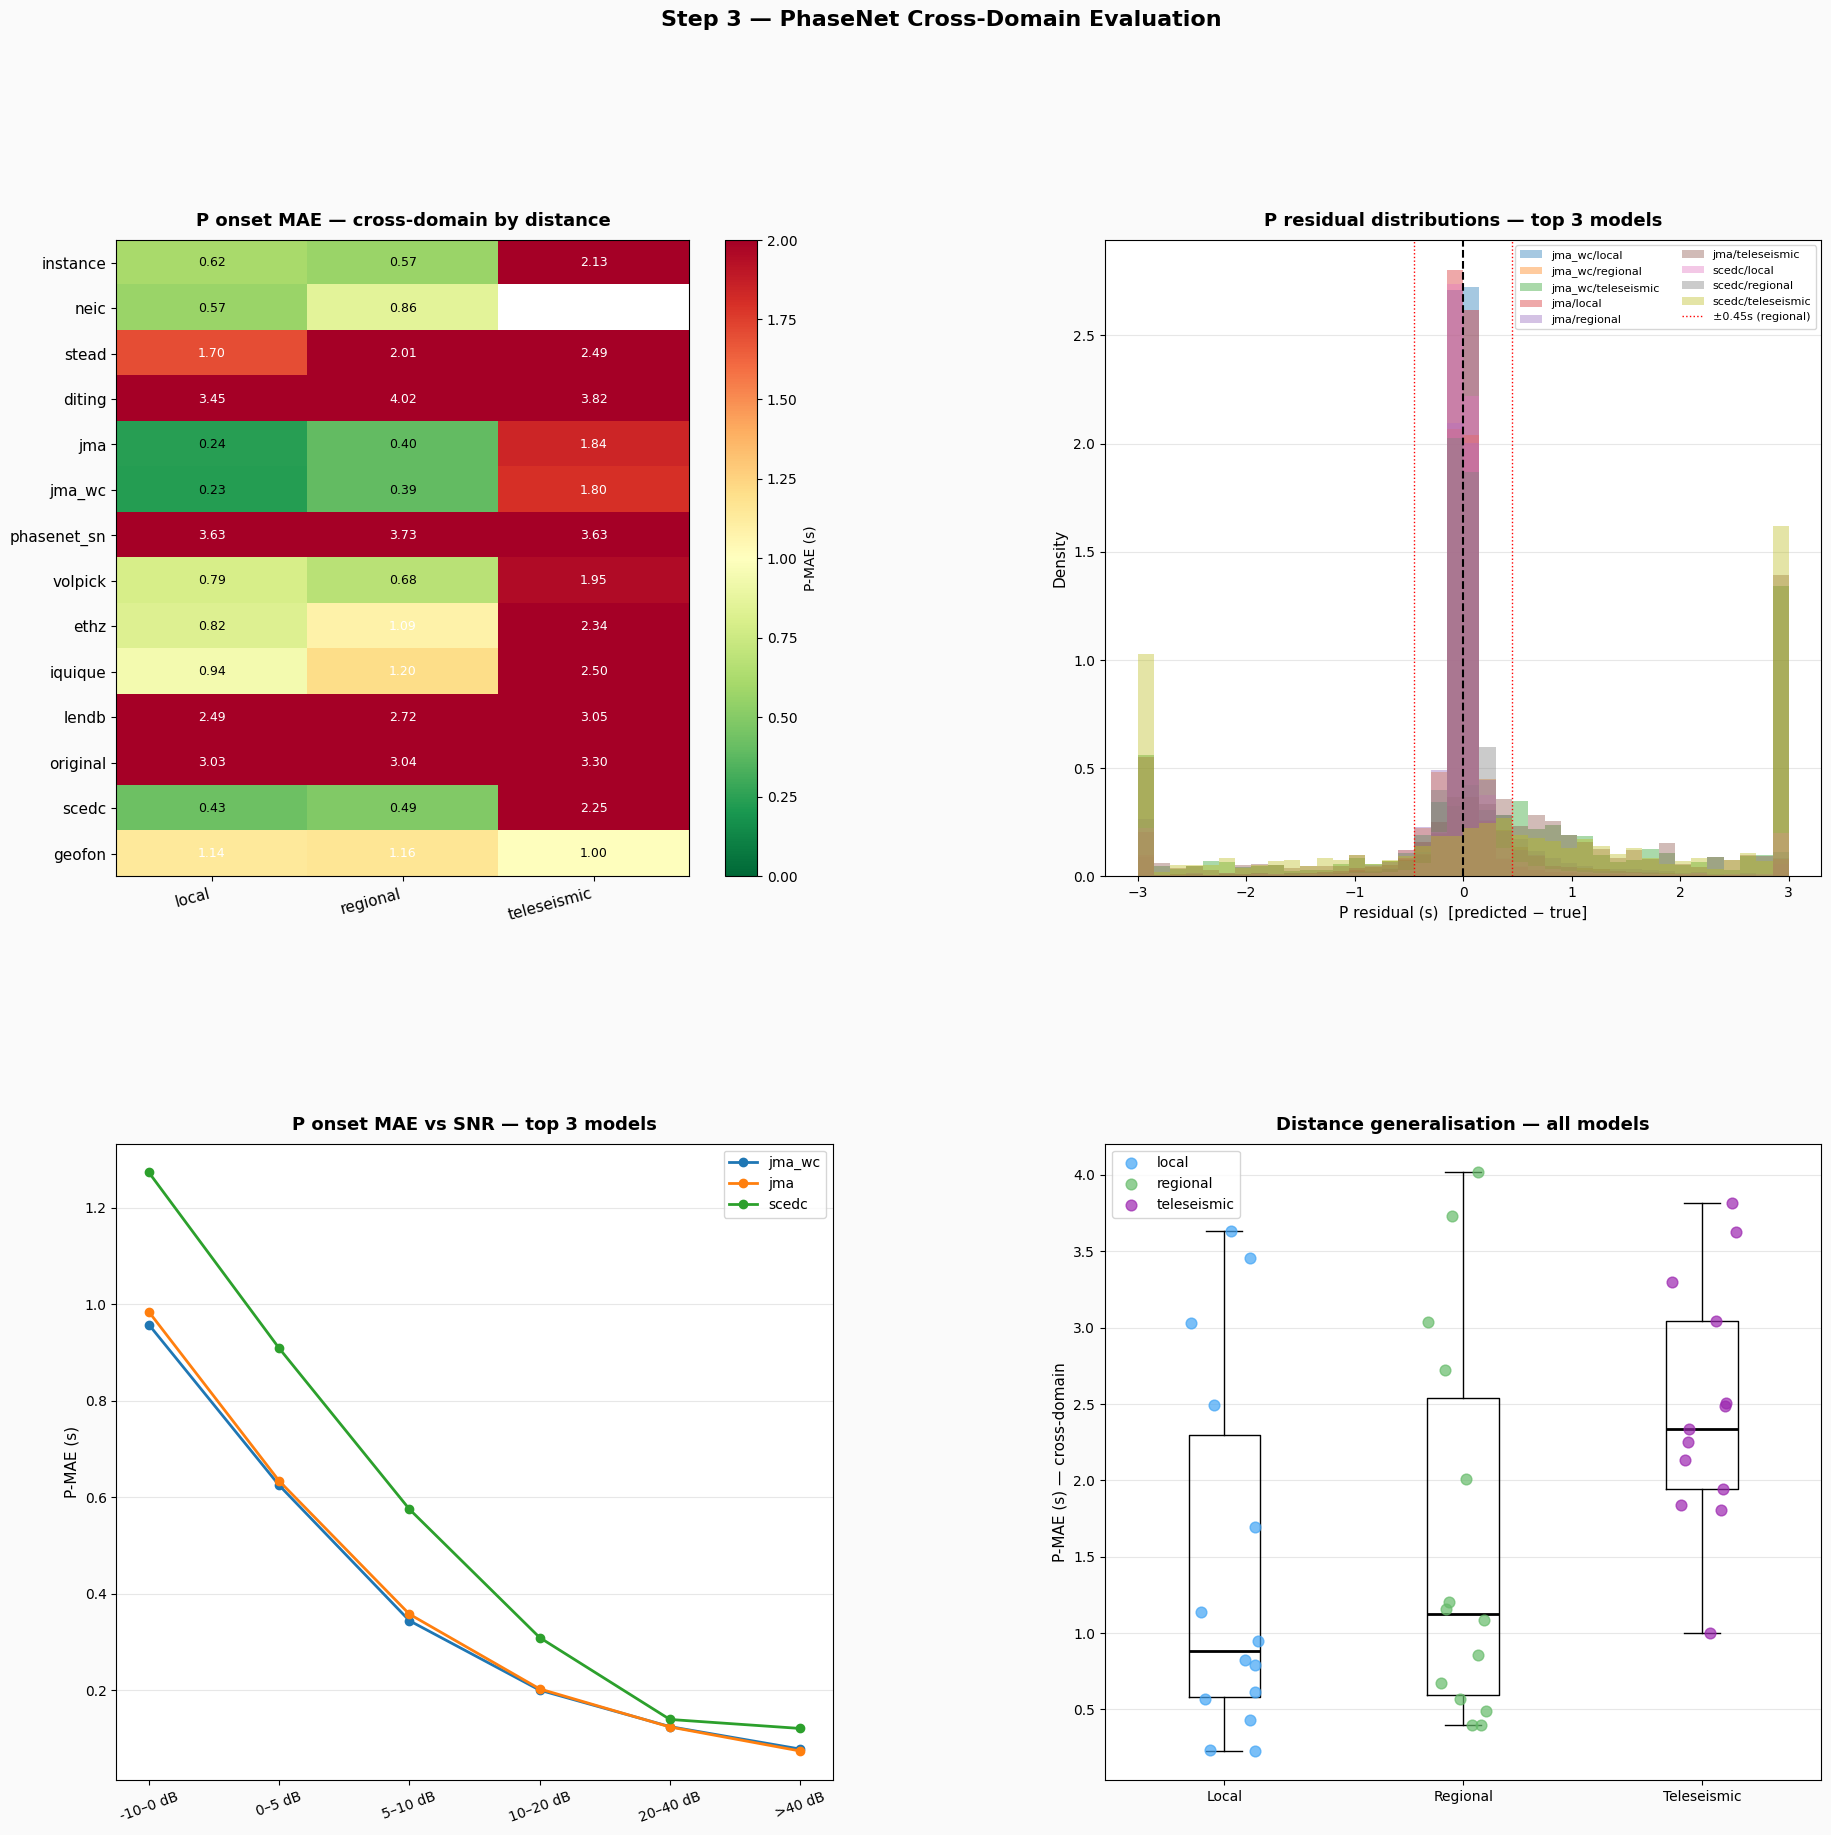

Saved → step3_results.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

metrics_df = pd.read_csv(METRICS_PATH)
results_df = pd.read_parquet(RESULTS_PATH)

TIER_COLORS = {"A":"#2196F3","B":"#FF9800","C":"#4CAF50","D":"#9C27B0"}
DIST_ORDER  = ["local (<150km)","regional (150-1500km)","teleseismic (>1500km)"]

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle("Step 3 — PhaseNet Cross-Domain Evaluation", fontsize=16,
             fontweight="bold", y=0.995)

# ── Panel 1: P-MAE heatmap (models × distance bins) ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cross = metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"].isin(DIST_ORDER))]
pivot = cross.pivot_table(index="weight", columns="dist_bin",
                           values="p_mae_s", aggfunc="first")
pivot = pivot.reindex(columns=DIST_ORDER)

# Sort by tier then mean MAE
pivot["_tier"] = [PHASENET_WEIGHTS.get(w,{}).get("tier","?") for w in pivot.index]
pivot = pivot.sort_values(["_tier","_tier"]).drop(columns=["_tier"])

im = ax1.imshow(pivot.values.astype(float), aspect="auto",
                cmap="RdYlGn_r", vmin=0, vmax=2.0)
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([c.split(" (")[0] for c in pivot.columns],
                     fontsize=11, rotation=15, ha="right")
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9, color="white" if val > 1.0 else "black")
plt.colorbar(im, ax=ax1, label="P-MAE (s)")
ax1.set_title("P onset MAE — cross-domain by distance", fontsize=13,
              fontweight="bold", pad=10)

# ── Panel 2: Residual distributions by distance ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top3 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nsmallest(3, "p_mae_s")["weight"].tolist())

for weight in top3:
    for dist in DIST_ORDER:
        sub = results_df[(results_df["weight"]==weight) &
                          (results_df["dist_bin"]==dist) &
                          (results_df["p_in_window"]>=0) &
                          (results_df["p_residual_s"].notna())]
        if len(sub) < 5: continue
        res = sub["p_residual_s"].clip(-3, 3)
        ax2.hist(res, bins=40, alpha=0.4, density=True, label=f"{weight}/{dist.split(' ')[0]}")

ax2.axvline(0, color="black", lw=1.5, linestyle="--")
ax2.axvline( OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":", label=f"±{OUTLIER_REGIONAL}s (regional)")
ax2.axvline(-OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":")
ax2.set_xlabel("P residual (s)  [predicted − true]", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("P residual distributions — top 3 models", fontsize=13,
              fontweight="bold", pad=10)
ax2.legend(fontsize=8, ncol=2)
ax2.tick_params(labelsize=10)
ax2.set_facecolor("white"); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# ── Panel 3: P-MAE vs SNR bins ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
snr_bins = [-10, 0, 5, 10, 20, 40, 100]
snr_labels = ["-10–0","0–5","5–10","10–20","20–40",">40"]

for weight in top3:
    wdf = results_df[(results_df["weight"]==weight) &
                      (results_df["p_in_window"]>=0) &
                      (results_df["p_residual_s"].notna())].copy()
    wdf["snr_bin"] = pd.cut(wdf["snr_db"], bins=snr_bins, labels=snr_labels)
    mae_by_snr = wdf.groupby("snr_bin", observed=True)["p_residual_s"].apply(
        lambda x: np.abs(x).mean())
    ax3.plot(range(len(mae_by_snr)), mae_by_snr.values, marker="o",
             linewidth=2, markersize=6, label=weight)

ax3.set_xticks(range(len(snr_labels)))
ax3.set_xticklabels([f"{l} dB" for l in snr_labels], fontsize=10, rotation=20)
ax3.set_ylabel("P-MAE (s)", fontsize=11)
ax3.set_title("P onset MAE vs SNR — top 3 models", fontsize=13,
              fontweight="bold", pad=10)
ax3.legend(fontsize=10)
ax3.tick_params(labelsize=10)
ax3.set_facecolor("white"); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── Panel 4: Teleseismic gap — all models ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cross_all = (metrics_df[(metrics_df["split"]=="cross_domain") &
                          (metrics_df["dist_bin"].isin(DIST_ORDER))]
             .pivot_table(index="weight", columns="dist_bin",
                          values="p_mae_s", aggfunc="first")
             .reindex(columns=DIST_ORDER))

x = np.arange(len(cross_all))
for j, dist in enumerate(DIST_ORDER):
    col_vals = cross_all[dist].values.astype(float)
    ax4.scatter(np.full(len(col_vals), j) + np.random.uniform(-0.15, 0.15, len(col_vals)),
                col_vals, s=60, alpha=0.7, zorder=3,
                color=["#42A5F5","#66BB6A","#9C27B0"][j], label=dist.split(" (")[0])

ax4.boxplot([cross_all[d].dropna().values for d in DIST_ORDER],
            positions=[0,1,2], widths=0.3, patch_artist=False,
            medianprops=dict(color="black",lw=2))
ax4.set_xticks([0,1,2])
ax4.set_xticklabels(["Local","Regional","Teleseismic"], fontsize=12)
ax4.set_ylabel("P-MAE (s) — cross-domain", fontsize=11)
ax4.set_title("Distance generalisation — all models", fontsize=13,
              fontweight="bold", pad=10)
ax4.legend(fontsize=10)
ax4.tick_params(labelsize=10)
ax4.set_facecolor("white"); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

plt.savefig("step3_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → step3_results.png")


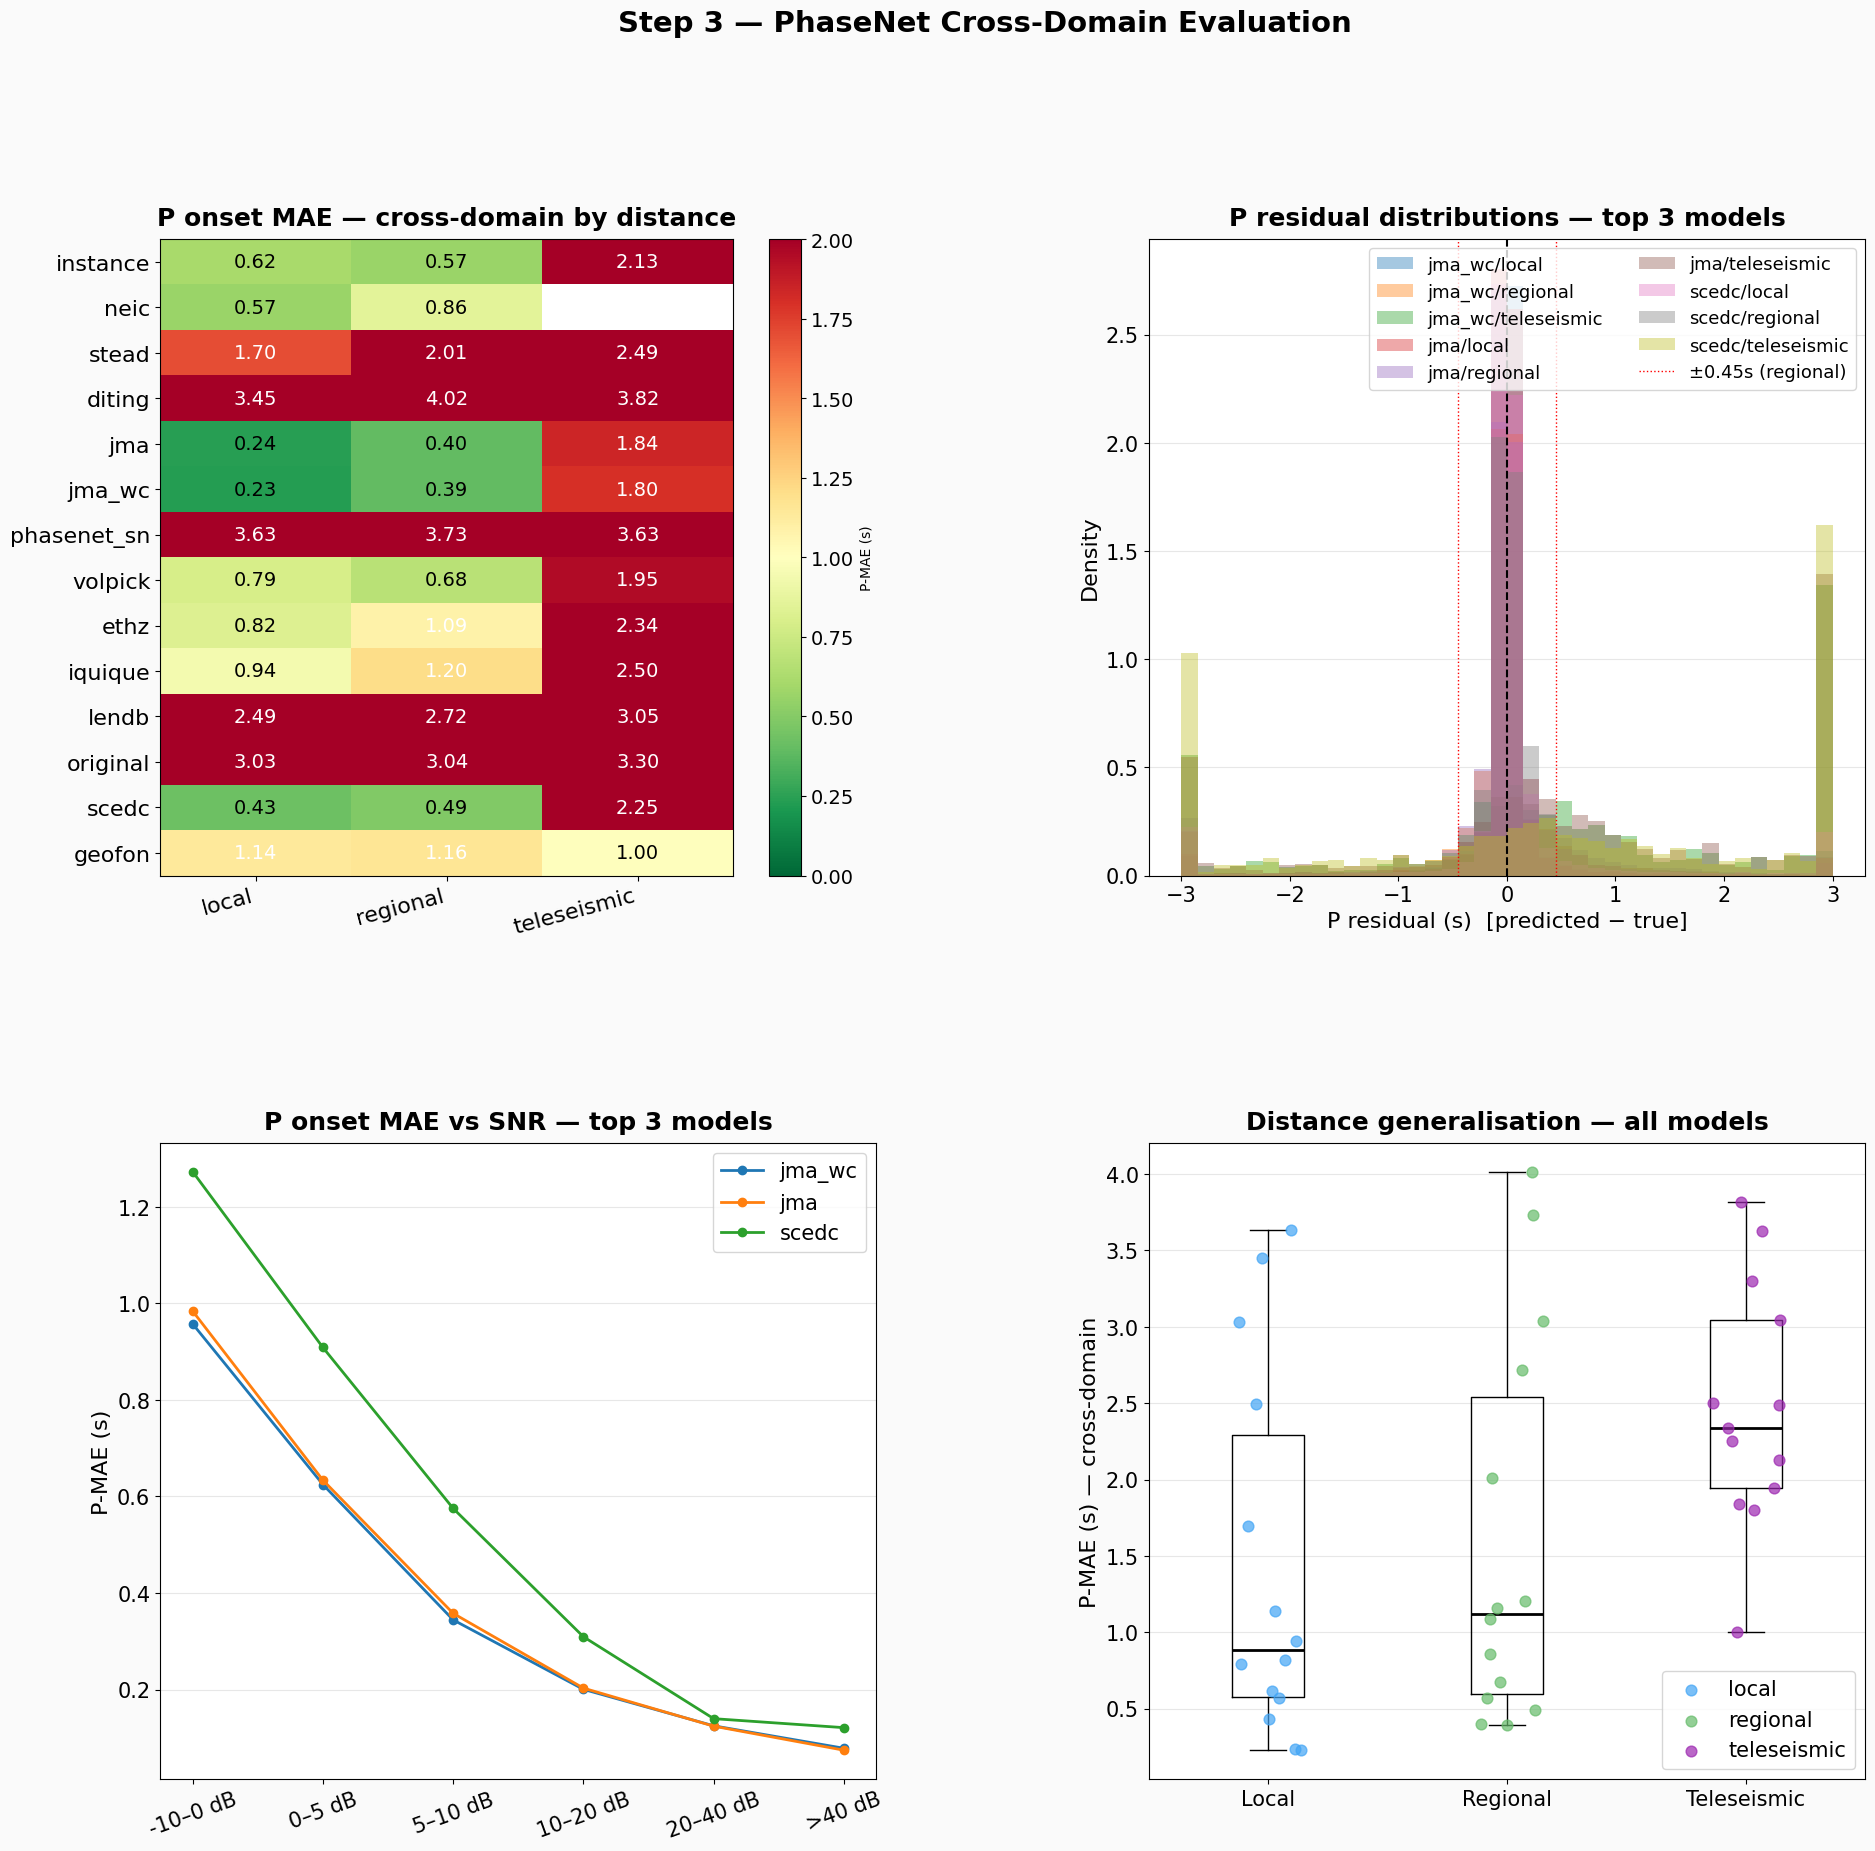

Saved → step3_results.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

metrics_df = pd.read_csv(METRICS_PATH)
results_df = pd.read_parquet(RESULTS_PATH)

TIER_COLORS = {"A":"#2196F3","B":"#FF9800","C":"#4CAF50","D":"#9C27B0"}
DIST_ORDER  = ["local (<150km)","regional (150-1500km)","teleseismic (>1500km)"]

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle("Step 3 — PhaseNet Cross-Domain Evaluation", fontsize=21,  # 16→21
             fontweight="bold", y=0.995)

# ── Panel 1: P-MAE heatmap ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cross = metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"].isin(DIST_ORDER))]
pivot = cross.pivot_table(index="weight", columns="dist_bin",
                           values="p_mae_s", aggfunc="first")
pivot = pivot.reindex(columns=DIST_ORDER)
pivot["_tier"] = [PHASENET_WEIGHTS.get(w,{}).get("tier","?") for w in pivot.index]
pivot = pivot.sort_values(["_tier","_tier"]).drop(columns=["_tier"])

im = ax1.imshow(pivot.values.astype(float), aspect="auto",
                cmap="RdYlGn_r", vmin=0, vmax=2.0)
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([c.split(" (")[0] for c in pivot.columns],
                     fontsize=16, rotation=15, ha="right")  # 11→16
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels(pivot.index, fontsize=16)  # 11→16
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=14, color="white" if val > 1.0 else "black")  # 9→14
plt.colorbar(im, ax=ax1, label="P-MAE (s)").ax.tick_params(labelsize=14)  # added tick size
ax1.set_title("P onset MAE — cross-domain by distance", fontsize=18,  # 13→18
              fontweight="bold", pad=10)

# ── Panel 2: Residual distributions ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top3 = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="all")]
        .nsmallest(3, "p_mae_s")["weight"].tolist())

for weight in top3:
    for dist in DIST_ORDER:
        sub = results_df[(results_df["weight"]==weight) &
                          (results_df["dist_bin"]==dist) &
                          (results_df["p_in_window"]>=0) &
                          (results_df["p_residual_s"].notna())]
        if len(sub) < 5: continue
        res = sub["p_residual_s"].clip(-3, 3)
        ax2.hist(res, bins=40, alpha=0.4, density=True, label=f"{weight}/{dist.split(' ')[0]}")

ax2.axvline(0, color="black", lw=1.5, linestyle="--")
ax2.axvline( OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":", label=f"±{OUTLIER_REGIONAL}s (regional)")
ax2.axvline(-OUTLIER_REGIONAL, color="red",  lw=1, linestyle=":")
ax2.set_xlabel("P residual (s)  [predicted − true]", fontsize=16)  # 11→16
ax2.set_ylabel("Density", fontsize=16)  # 11→16
ax2.set_title("P residual distributions — top 3 models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax2.legend(fontsize=13, ncol=2)  # 8→13
ax2.tick_params(labelsize=15)  # 10→15
ax2.set_facecolor("white"); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

# ── Panel 3: P-MAE vs SNR bins ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
snr_bins = [-10, 0, 5, 10, 20, 40, 100]
snr_labels = ["-10–0","0–5","5–10","10–20","20–40",">40"]

for weight in top3:
    wdf = results_df[(results_df["weight"]==weight) &
                      (results_df["p_in_window"]>=0) &
                      (results_df["p_residual_s"].notna())].copy()
    wdf["snr_bin"] = pd.cut(wdf["snr_db"], bins=snr_bins, labels=snr_labels)
    mae_by_snr = wdf.groupby("snr_bin", observed=True)["p_residual_s"].apply(
        lambda x: np.abs(x).mean())
    ax3.plot(range(len(mae_by_snr)), mae_by_snr.values, marker="o",
             linewidth=2, markersize=6, label=weight)

ax3.set_xticks(range(len(snr_labels)))
ax3.set_xticklabels([f"{l} dB" for l in snr_labels], fontsize=15, rotation=20)  # 10→15
ax3.set_ylabel("P-MAE (s)", fontsize=16)  # 11→16
ax3.set_title("P onset MAE vs SNR — top 3 models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax3.legend(fontsize=15)  # 10→15
ax3.tick_params(labelsize=15)  # 10→15
ax3.set_facecolor("white"); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)

# ── Panel 4: Teleseismic gap ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cross_all = (metrics_df[(metrics_df["split"]=="cross_domain") &
                          (metrics_df["dist_bin"].isin(DIST_ORDER))]
             .pivot_table(index="weight", columns="dist_bin",
                          values="p_mae_s", aggfunc="first")
             .reindex(columns=DIST_ORDER))

x = np.arange(len(cross_all))
for j, dist in enumerate(DIST_ORDER):
    col_vals = cross_all[dist].values.astype(float)
    ax4.scatter(np.full(len(col_vals), j) + np.random.uniform(-0.15, 0.15, len(col_vals)),
                col_vals, s=60, alpha=0.7, zorder=3,
                color=["#42A5F5","#66BB6A","#9C27B0"][j], label=dist.split(" (")[0])

ax4.boxplot([cross_all[d].dropna().values for d in DIST_ORDER],
            positions=[0,1,2], widths=0.3, patch_artist=False,
            medianprops=dict(color="black",lw=2))
ax4.set_xticks([0,1,2])
ax4.set_xticklabels(["Local","Regional","Teleseismic"], fontsize=17)  # 12→17
ax4.set_ylabel("P-MAE (s) — cross-domain", fontsize=16)  # 11→16
ax4.set_title("Distance generalisation — all models", fontsize=18,  # 13→18
              fontweight="bold", pad=10)
ax4.legend(fontsize=15)  # 10→15
ax4.tick_params(labelsize=15)  # 10→15
ax4.set_facecolor("white"); ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

plt.savefig("step3_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → step3_results.png")

## 3.7  Thesis-Ready Results Table


In [22]:
metrics_df = pd.read_csv(METRICS_PATH)

# ── Full results table: cross-domain, per distance bin ────────────────────
table = (metrics_df[metrics_df["split"] == "cross_domain"]
         .pivot_table(index=["tier","weight"],
                      columns="dist_bin",
                      values=["p_mae_s","p_recall","mcc"],
                      aggfunc="first")
         .round(3))

print("Cross-domain results by distance bin")
print("Columns: p_mae_s (P onset MAE in seconds) | p_recall | mcc (phase ID)")
print("=" * 100)
print(table.to_string())

# ── Key finding: teleseismic gap ──────────────────────────────────────────
tele = (metrics_df[(metrics_df["split"]=="cross_domain") &
                    (metrics_df["dist_bin"]=="teleseismic (>1500km)")]
        .sort_values("p_mae_s")[["weight","tier","n_traces","p_recall","p_mae_s","mcc"]])

print("\n\nTeleseismic cross-domain performance (sorted by P-MAE):")
print(tele.to_string(index=False))

# Save formatted table for thesis
table.to_csv("step3_thesis_table.csv")
tele.to_csv("step3_teleseismic_table.csv", index=False)
print("\nSaved step3_thesis_table.csv and step3_teleseismic_table.csv")


Cross-domain results by distance bin
Columns: p_mae_s (P onset MAE in seconds) | p_recall | mcc (phase ID)
                    mcc                                      p_mae_s                                                            p_recall                                                           
dist_bin            all local (<150km) regional (150-1500km)     all local (<150km) regional (150-1500km) teleseismic (>1500km)      all local (<150km) regional (150-1500km) teleseismic (>1500km)
tier weight                                                                                                                                                                                        
A    instance     0.744          0.713                 0.825   0.688          0.615                 0.570                 2.130    0.604          0.670                 0.590                 0.177
     neic         0.495          0.500                 0.476   0.702          0.567                 0.855    